In [ ]:
#Setting up the database sector and importing the packages
import pandas as pd
import numpy as np
import re
from nltk.tokenize import RegexpTokenizer
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from gensim import corpora, models
from gensim.models import CoherenceModel
stop_words = stopwords.words('danish')
df = pd.read_csv('/Users/lucasaranagy/Desktop/Thesis/sectordatabase.csv')

In [ ]:
df.head()
df.info()
#df_dropped = df.drop_duplicates(keep='first')

In [4]:
#Create df from ads only
df_ads = df["raw_head"]
df_ads=df_ads.tolist()

#Create list of locations to be dropped from ads
location_list = df["location"]
location_list = location_list.dropna()
location_list = location_list.drop_duplicates(keep = 'first')
location_list = pd.DataFrame(location_list)
location_list = location_list.reset_index()
loc_list = location_list["location"]

#Tokenize locations
tokenizer = RegexpTokenizer(r'\w+')
df_t=[]
for i in range(len(loc_list)):
    raw = loc_list[i].lower()
    tokens = tokenizer.tokenize(raw)
    df_t.append(tokens)

loc_list = df_t

In [5]:
#Extend stopwords with words that won't be filtered aout but are noise
stop_words.extend(['bruger', 'cookies', 'mail', 'e-mail', 'email', 'to', 'contact', 'region', 'denmark', 'movia'
                   'toggle', 'navigation', 'close', 'meny', 'mailto', 'derfor', 'komme', 'så', 'jobindex'])

In [6]:
#Tokenize and remove stopwords

df_punc_rem=[]
df_digit_rem=[]
df_t = []
df_s=[]
pattern = r'[0-9]'

for i in range(len(df_ads)):
    df_punc_rem.append(re.sub(r'[^\w\s]', '', df_ads[i]))
    df_digit_rem.append(re.sub(pattern,'',df_punc_rem[i]))
    raw = df_digit_rem[i].lower()
    tokens = tokenizer.tokenize(raw)
    df_t.append(tokens)
    stopped = [j for j in df_t[i] if not j in stop_words]
    df_s.append(stopped)

In [7]:
#Create list with locations removed
texts_loc = []
for i in range(len(df_s)):
    loc = [j for j in df_s[i] if not j in loc_list]
    texts_loc.append(loc)

In [8]:
from gensim.models import Phrases
#Create bigrams
bigram = gensim.models.Phrases(texts_loc, min_count = 5, threshold = 100)
#trigram = gensim.models.Phrases(bigram[texts_loc], threshold = 100)

In [9]:
bigram_mod = gensim.models.phrases.Phraser(bigram)
#trigram_mod = gensim.models.phrases.Phraser(trigram)

In [10]:
def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

In [11]:
texts = make_bigrams(texts_loc)

In [ ]:
#Use stemmer, but here lemmatizing is more appropiate
#from nltk.stem import SnowballStemmer
#stemmer = SnowballStemmer('danish')
#texts_stemmed=[]
#for i in range(len(texts)):
 #   stemmed=[stemmer.stem(j) for j in texts[i]]
  #  texts_stemmed.append(stemmed)  

In [ ]:
#Import Danish pipeline from SpaCy
import spacy
!python -m spacy download da_core_news_sm
nlp = spacy.load('da_core_news_sm')

In [13]:
def lemmatization(texts, allowed_postags=['PNOUN', 'NOUN', 'ADJ', 'VERB', 'ADV']):
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent)) 
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

In [14]:
#Lemmatize texts with SpaCy Danish lemmatizer
text_lemmatized = lemmatization(texts, allowed_postags = ['PNOUN', 'NOUN', 'ADJ', 'VERB', 'ADV'])

In [ ]:
#Check output
text_lemmatized[200:400]

In [ ]:
#Check frequent words
from itertools import chain
words=list(chain(*text_lemmatized))
freq=FreqDist(words)
freq.most_common(100)

In [17]:
#Create dictionary, set frequency thresholds
dictionary = corpora.Dictionary(text_lemmatized)
dictionary.filter_extremes(no_below=15, no_above=0.6, keep_n = 100000)

In [18]:
#Create corpus with bag-of-words
corpus = [dictionary.doc2bow(doc) for doc in text_lemmatized]

In [ ]:
#Check dictionary length
len(dictionary)

In [ ]:
print(corpus[:2])

In [ ]:
#Create iteration loop

#Setting up the basics for iteration
import tqdm
grid = {}
grid['Validation_Set'] = {}
# Topics range
min_topics = 20
max_topics = 101
step_size = 5
topics_range = range(min_topics, max_topics, step_size)
# Alpha parameter
alpha = []
alpha.append('symmetric')
alpha.append('asymmetric')
#alpha.append('auto')
#Beta parameter
beta = [0.1]
#beta.append('symmetric')

corpus_sets = [ gensim.utils.ClippedCorpus(corpus, int(len(corpus)*0.8)), 
               corpus]

corpus_title = ['80% Courpus','100% Corpus']
model_results = {'Validation_Set': [],
                 'Topics': [],
                 'Alpha': [],
                 'Beta': [],
                 'C_NPMI': [],
                 'C_uci': [],
                 'C_mass': []
                }

if 1 == 1:
    pbar = tqdm.tqdm(total=540)
# Corpus sets
for i in range(len(corpus_sets)):
    #Topics
    for k in topics_range:
        #Alpha
        for a in alpha:
            #Eta
            for b in beta:
                # Coherence scores for the models
                lda_model = gensim.models.LdaMulticore(corpus=corpus_sets[i],
                                           id2word=dictionary,
                                           num_topics=k, 
                                           random_state=100,
                                           chunksize=len(corpus_sets[i]),
                                           passes=10,
                                           eta=b,
                                           alpha=a)
                coherence_model_lda_npmi = CoherenceModel(model=lda_model, texts=text_lemmatized, dictionary=dictionary, coherence='c_npmi')
                npmi = coherence_model_lda_npmi.get_coherence()
                coherence_model_lda_mass = CoherenceModel(model=lda_model, texts=text_lemmatized, dictionary=dictionary, coherence='u_mass')
                mass = coherence_model_lda_mass.get_coherence()
                coherence_model_lda_uci = CoherenceModel(model=lda_model, texts=text_lemmatized, dictionary=dictionary, coherence='c_uci')
                uci = coherence_model_lda_uci.get_coherence()
                #Save results
                model_results['Validation_Set'].append(corpus_title)
                model_results['Topics'].append(k)
                model_results['Alpha'].append(a)
                model_results['Beta'].append(b)
                model_results['C_mass'].append(mass)
                model_results['C_uci'].append(uci)
                model_results['C_NPMI'].append(npmi)
                    
                pbar.update(1)
pd.DataFrame(model_results).to_csv('lda_tuning_results_database2.csv', index=False)
pbar.close()

In [26]:
import matplotlib.pyplot as plt

In [27]:
model_results_df = pd.DataFrame(model_results)

In [28]:
#Tuning results
model_results_df

,Validation_Set,Topics,Alpha,Beta,C_NPMI,C_uci,C_mass
0,"[80% Courpus, 100% Corpus]",20,symmetric,0.1,-0.018981,-0.360416,-1.030354
1,"[80% Courpus, 100% Corpus]",20,asymmetric,0.1,-0.021996,-0.395299,-1.050991
2,"[80% Courpus, 100% Corpus]",25,symmetric,0.1,-0.021215,-0.454175,-1.080194
3,"[80% Courpus, 100% Corpus]",25,asymmetric,0.1,-0.021649,-0.474062,-1.063059
4,"[80% Courpus, 100% Corpus]",30,symmetric,0.1,-0.021775,-0.546143,-1.050915
...,...,...,...,...,...,...,...
63,"[80% Courpus, 100% Corpus]",90,asymmetric,0.1,-0.040657,-1.489836,-1.709356
64,"[80% Courpus, 100% Corpus]",95,symmetric,0.1,-0.041767,-1.445369,-1.786928
65,"[80% Courpus, 100% Corpus]",95,asymmetric,0.1,-0.041303,-1.460121,-1.814122
66,"[80% Courpus, 100% Corpus]",100,symmetric,0.1,-0.041054,-1.564026,-1.840851


In [32]:
#Plot tuning results to select optimal K
plot_df_asym = model_results_df[model_results_df["Alpha"] == "asymmetric"]
plot_df_sym = model_results_df[model_results_df["Alpha"] == "symmetric"]
plot_df_asym_80=plot_df_asym.iloc[0:16]
plot_df_asym_80
plot_df_asym_100=plot_df_asym.iloc[17:34]
plot_df_asym_100
plot_df_sym = model_results_df[model_results_df["Alpha"] == "symmetric"]
plot_df_sym_80=plot_df_sym.iloc[0:16]

/Users/lucasaranagy/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


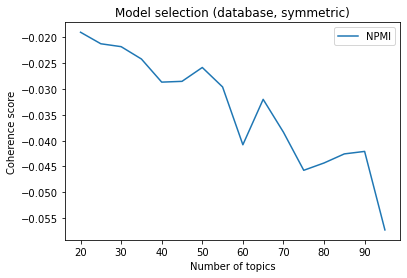

In [58]:
x = plot_df_sym_80["Topics"]
npmi = plot_df_sym_80["C_NPMI"]
plt.plot(x,npmi, label='NPMI')
plt.legend()
plt.title("Model selection (database, symmetric)")
plt.ylabel("Coherence score")
plt.xlabel("Number of topics")
#plt.savefig("da.png")

# uci and mass shows k=60
#npmi shows 30

/Users/lucasaranagy/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


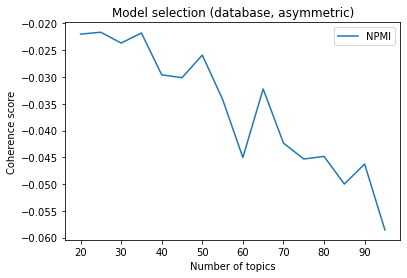

In [59]:
x = plot_df_asym_80["Topics"]
npmi = plot_df_asym_80["C_NPMI"]
plt.plot(x,npmi, label='NPMI')
plt.legend()
plt.title("Model selection (database, asymmetric)")
plt.ylabel("Coherence score")
plt.xlabel("Number of topics")
#plt.savefig("db.png")

/Users/lucasaranagy/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


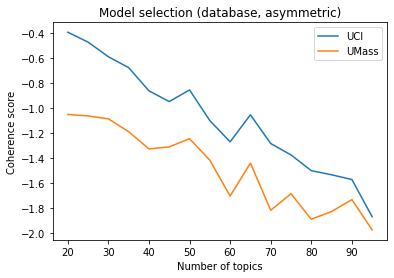

In [60]:
x = plot_df_asym_80["Topics"]
uci= plot_df_asym_80["C_uci"]
mass= plot_df_asym_80["C_mass"]
plt.plot(x,uci, label='UCI')
plt.plot(x,mass, label='UMass')
plt.legend()
plt.title("Model selection (database, asymmetric)")
plt.ylabel("Coherence score")
plt.xlabel("Number of topics")
#plt.savefig("dc.png")

/Users/lucasaranagy/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


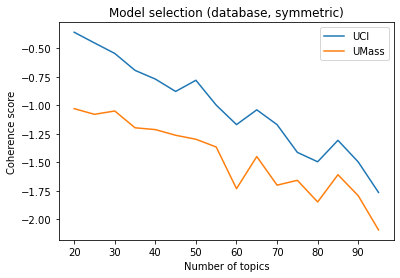

In [61]:
x = plot_df_sym_80["Topics"]
uci= plot_df_sym_80["C_uci"]
mass= plot_df_sym_80["C_mass"]
plt.plot(x,uci, label='UCI')
plt.plot(x,mass, label='UMass')
plt.legend()
plt.title("Model selection (database, symmetric)")
plt.ylabel("Coherence score")
plt.xlabel("Number of topics")
#plt.savefig("dd.png")

In [37]:
#Model with optimal k
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=35, 
                                           random_state=100,
                                           chunksize=len(corpus),
                                           passes=10,
                                           alpha="asymmetric",
                                           eta=0.1)

In [ ]:
## import pyLDAvis.gensim_models
import pickle 
import pyLDAvis
# Visualize the topics
pyLDAvis.enable_notebook()
LDAvis_prepared = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
LDAvis_prepared

In [ ]:
model35_results = pd.DataFrame(lda_model.print_topics(num_topics = 35, num_words=30))

In [41]:
#Topic-word weight table
model35_results_split = model35_results[1].str.split('+', expand=True)
model35_results_split

/Users/lucasaranagy/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,"0.046*""data""","0.009*""skabe""","0.007*""virksomhed""","0.005*""analyse""","0.005*""komme""","0.004*""sammen""","0.004*""gøre""","0.004*""microsoft""","0.004*""forvente""","0.004*""fokus""",...,"0.003*""ansvar""","0.003*""machine_learning""","0.003*""forskellig""","0.003*""år""","0.003*""sikker""","0.003*""fagligt""","0.003*""høj""","0.003*""tage""","0.003*""sætte""","0.003*""vigtig"""
1,"0.023*""virksomhed""","0.006*""data""","0.006*""kunde""","0.006*""se""","0.005*""tilbyde""","0.005*""personlig""","0.005*""brug""","0.005*""information""","0.004*""ønske""","0.004*""herunder""",...,"0.003*""læse""","0.003*""system""","0.003*""kendskab""","0.003*""produkt""","0.003*""fordel""","0.003*""luk_følg""","0.003*""kontakt""","0.003*""hjemmesid""","0.003*""modtage""","0.003*""as"""
2,"0.022*""kunde""","0.014*""bank""","0.007*""søg""","0.006*""ansvar""","0.006*""gøre""","0.006*""fokus""","0.005*""systematic""","0.005*""tæt""","0.005*""høj""","0.005*""spændende""",...,"0.004*""brug""","0.004*""velkommen_kontakte""","0.004*""tilbyde""","0.004*""ligne""","0.004*""stærk""","0.004*""hel""","0.004*""software""","0.003*""skabe""","0.003*""kollegaa""","0.003*""forretning"""
3,"0.014*""kunde""","0.011*""netcompany""","0.011*""data""","0.009*""projekt""","0.008*""ansvar""","0.008*""tage""","0.008*""karriere""","0.007*""hverdag""","0.007*""faglig""","0.006*""dygtig""",...,"0.005*""drift""","0.004*""udfordre""","0.004*""år""","0.004*""unik""","0.004*""stå""","0.004*""sammen""","0.004*""niveau""","0.004*""branche""","0.004*""lære""","0.004*""ønske"""
4,"0.011*""virksomhed""","0.010*""kunde""","0.006*""tilbyde""","0.006*""teknisk""","0.006*""gerne""","0.005*""spørgsmål""","0.005*""spændende""","0.005*""as""","0.005*""ansvar""","0.005*""komme""",...,"0.004*""produkt""","0.004*""dygtig""","0.004*""viden""","0.004*""høj""","0.004*""indgå""","0.004*""år""","0.003*""mange""","0.003*""hel""","0.003*""miljø""","0.003*""fordel"""
5,"0.011*""stat""","0.007*""data""","0.007*""herunder""","0.006*""drift""","0.005*""organisation""","0.005*""teknisk""","0.005*""kendskab""","0.005*""relevant""","0.005*""forvente""","0.005*""fokus""",...,"0.003*""mange""","0.003*""modtage""","0.003*""forskning""","0.003*""skabe""","0.003*""universitet""","0.003*""forskellig""","0.003*""sikker""","0.003*""kontakt""","0.003*""afdeling""","0.003*""system"""
6,"0.010*""data""","0.007*""styrels""","0.006*""analyse""","0.006*""kunde""","0.006*""relevant""","0.005*""forskellig""","0.005*""forvente""","0.005*""levere""","0.005*""søg""","0.005*""læse""",...,"0.004*""se""","0.004*""høj""","0.004*""agile""","0.004*""komme""","0.004*""kontakt""","0.004*""arbejdsopgave""","0.004*""application""","0.004*""faglighed""","0.004*""vide""","0.004*""brug"""
7,"0.013*""itsikkerhed""","0.010*""informationssikkerhed""","0.009*""sikkerhed""","0.008*""teknisk""","0.007*""organisation""","0.007*""sikker""","0.006*""ansvar""","0.005*""skabe""","0.005*""sammen""","0.005*""forvente""",...,"0.004*""tæt""","0.004*""krav""","0.004*""implementering""","0.004*""infrastruktur""","0.004*""relevant""","0.003*""hel""","0.003*""høj""","0.003*""arbejdsplads""","0.003*""tilbyde""","0.003*""kendskab"""
8,"0.025*""kommune""","0.012*""organisation""","0.007*""data""","0.007*""digitalisering""","0.006*""gerne""","0.006*""relevant""","0.005*""leder""","0.005*""faglig""","0.005*""viden""","0.005*""baggrund""",...,"0.004*""skabe""","0.004*""indgå""","0.004*""forvente""","0.003*""analyse""","0.003*""uddannelse""","0.003*""evne""","0.003*""forhold""","0.003*""sammen""","0.003*""tværs""","0.003*""fælles"""
9,"0.013*""data""","0.010*""politi""","0.010*""analyse""","0.006*""ansvar""","0.005*""forskellig""","0.005*""tværs""","0.005*""relevant""","0.005*""organisation""","0.005*""hel""","0.004*""søg""",...,"0.003*""dansk""","0.003*""høj""","0.003*""sikker""","0.003*""forvente""","0.003*""samtale""","0.003*""information""","0.003*""fordel""","0.003*""sikre""","0.003*""evne""","

In [ ]:
model35_results_split.to_csv('database_k35.csv', index=True)

In [ ]:
topics = [lda_model[corpus[i]] for i in range(len(corpus))]
#len(text_lemmatized)
#len(corpus)

In [ ]:
topics_df= pd.DataFrame(topics)

In [ ]:
topics_df.to_csv('marketing_topics.csv', index=True)

In [ ]:
topics2=[]
for t in range(len(topics)):
    list_ = []
    for i in range(len(topics[t])):
        for j in range(len(topics[t][i])): 
            list_.append(topics[t][i][j])
    topics2.append(list_)

In [52]:
#Topic number and weight is split, probability of ad belonging to specific topic
topics2_df = pd.DataFrame(topics2)
topics2_df

/Users/lucasaranagy/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,0,1,2,3,4,5,6,7,8,9,...,60,61,62,63,64,65,66,67,68,69
0,1,0.819156,4.0,0.012372,26.0,0.122230,30.0,0.042039,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,0.033559,26.0,0.959851,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.239411,4.0,0.345398,8.0,0.167851,20.0,0.114053,21.0,0.106089,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,0.220591,7.0,0.071578,27.0,0.704696,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0.185397,1.0,0.374014,4.0,0.057613,6.0,0.139395,26.0,0.175525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6473,30,0.992046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6474,1,0.488105,10.0,0.304632,11.0,0.201663,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6475,1,0.181745,2.0,0.038994,4.0,0.135631,5.0,0.111260,31.0,0.494268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6476,0,0.317368,4.0,0.097276,11.0,0.400251,19.0,0.110780,22.0,0.060915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#topics2_df.to_csv('database35_topics2.csv', index=True)